# NYC Jobs - Data Engineering Coding Assessment

**Dataset:** NYC Job Postings (nyc-jobs.csv) — Current job postings hosted by the City of New York  
**Tool:** PySpark on Databricks  
**Author:** Data Engineering Candidate

---

## Table of Contents
1. **Setup & Data Loading** — Import libraries and load the dataset
2. **Data Exploration** — Detailed analysis of columns, data types, distributions
3. **KPI Analysis** — Six key performance indicators
4. **Data Processing** — Cleaning
5. **Test Cases** — Unit tests for processing functions
6. **Deployment & Triggering** — Proposals for production deployment

In [0]:
# =============================================================================
# STEP 1: Import all required libraries
# =============================================================================
# PySpark core
from pyspark.sql import SparkSession, DataFrame
from pyspark.sql import functions as F
from pyspark.sql.types import (
    StructType, StructField, StringType, IntegerType,
    DoubleType, DateType, TimestampType
)
from pyspark.sql.window import Window

# Python standard libraries
import re
from datetime import datetime

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import numpy as np

print("All libraries imported successfully!")
print(f"Spark version: {spark.version}")

All libraries imported successfully!
Spark version: 4.1.0


In [0]:
# =============================================================================
# STEP 2: Load the NYC Jobs CSV into a Spark DataFrame
# =============================================================================
# Path to the CSV file in the Databricks workspace
CSV_PATH = "/Workspace/Users/rakshitha/Personal_Projects/nyc-jobs.csv"

# Read CSV with header and infer schema for initial exploration
# multiLine=True handles fields that span multiple lines (e.g., Job Description)
df_raw = (
    spark.read
    .option("header", "true")
    .option("inferSchema", "true")
    .option("multiLine", "true")
    .option("escape", '"')
    .csv(CSV_PATH)
)

# Display basic info
print(f"Total number of records: {df_raw.count()}")
print(f"Total number of columns: {len(df_raw.columns)}")
print(f"\nColumn names:")
for i, col in enumerate(df_raw.columns, 1):
    print(f"  {i:2d}. {col}")

Total number of records: 2946
Total number of columns: 28

Column names:
   1. Job ID
   2. Agency
   3. Posting Type
   4. # Of Positions
   5. Business Title
   6. Civil Service Title
   7. Title Code No
   8. Level
   9. Job Category
  10. Full-Time/Part-Time indicator
  11. Salary Range From
  12. Salary Range To
  13. Salary Frequency
  14. Work Location
  15. Division/Work Unit
  16. Job Description
  17. Minimum Qual Requirements
  18. Preferred Skills
  19. Additional Information
  20. To Apply
  21. Hours/Shift
  22. Work Location 1
  23. Recruitment Contact
  24. Residency Requirement
  25. Posting Date
  26. Post Until
  27. Posting Updated
  28. Process Date


In [0]:
# Show first 5 rows to understand the data structure

display(df_raw.limit(5))

Job ID Agency Posting Type # Of Positions Business Title Civil Service Title Title Code No Level Job Category Full-Time/Part-Time indicator Salary Range From Salary Range To Salary Frequency Work Location Division/Work Unit Job Description Minimum Qual Requirements Preferred Skills Additional Information To Apply Hours/Shift Work Location 1 Recruitment Contact Residency Requirement Posting Date Post Until Posting Updated Process Date 87990 DEPARTMENT OF BUSINESS SERV. Internal 1 Account Manager CONTRACT REVIEWER (OFFICE OF L 40563 1 null null 42405.0 65485.0 Annual 110 William St. N Y Strategy & Analytics Division of Economic & Financial Opportunity (DEFO) Mayor Michael R. Bloomberg and SBS are committed to encouraging a competitive and diverse New York City business environment by promoting the growth and success of minority and women-owned companies. New York Cityâ€™s Minority and Women-owned Business Enterprise (M/WBE) program is designed to help these historically underserved groups become more competitive. JOB DESCRIPTION The Account Manager will provide a range of supportive services to City agency purchasing personnel and private-sector prime contractors to help them comply with M/WBE utilization goals under Local Law 129. The Account Manager will oversee a portfolio of several City agencies and will be responsible for the monitoring and oversight of the strategies which have been broadly laid out for agencies to increase M/WBE utilization. The primary objective for the Account Manager is to help agencies increase the number and dollar value of contracts awarded to M/WBE at various contract levels. Specifically, the Account Manager will seek to bring agencies into compliance with the Citywide utilization goals and other metrics used for measuring agency performance. Each account manager will be responsible for procurements of all sizes and methods for their respective agencies. The Account Manager will report to the Director of Procurement Initiatives. Account Manager Model Each agency has very specific vendor requirements and needs, as well as obstacles to increasing M/WBE Utilization. The account managers will learn what is procured, by what method, how frequently, and how to get more M/WBEs participating in the process. The account manager will leverage their procurement contacts to work directly with program end users to identify needs and obstacles and create appropriate solutions. The Account Managerâ€™s responsibilities will include the following: 1.	Research agency procurement practices, requirements, in order to connect M/WBE firms with future procurement opportunities 2.	Work with the agency senior staff to implement strategies to increase M/WBE participation 3.	Introduce new M/WBE firms to agency staff 4.	Assist agency staff with tools to improve performance, including monitoring prime contractor performance relating to M/WBE subcontractor utilization goals 5.	Inform agency senior staff of their performance against goals on a regular basis 6.	Assist program and procurement staff with program implementation questions as they arise 7.	Produce analysis of agency contracts and M/WBE program performance 8.	Coordinate resources for agencies as necessary, including networking events, training sessions, etc. 1.	A baccalaureate degree from an accredited college and two years of experience in community work or community centered activities in an area related to the duties described above; or 2.	High school graduation or equivalent and six years of experience in community work or community centered activities in an area related to the duties as described above; or 3.	Education and/or experience which is equivalent to "1" or "2" above. However, all candidates must have at least one year of experience as described in "1" above. â€¢	Excellent interpersonal and organizational skills. â€¢	Excellent analytic and operational skills. â€¢	Excellent writing and editing skills. â€¢	Knowledge of government procurement processes and

In [0]:
for field in df_raw.schema.fields:
    print(field, "---->", field.name, "---->", field.dataType)

StructField('Job ID', IntegerType(), True) ----> Job ID ----> IntegerType()
StructField('Agency', StringType(), True) ----> Agency ----> StringType()
StructField('Posting Type', StringType(), True) ----> Posting Type ----> StringType()
StructField('# Of Positions', IntegerType(), True) ----> # Of Positions ----> IntegerType()
StructField('Business Title', StringType(), True) ----> Business Title ----> StringType()
StructField('Civil Service Title', StringType(), True) ----> Civil Service Title ----> StringType()
StructField('Title Code No', StringType(), True) ----> Title Code No ----> StringType()
StructField('Level', StringType(), True) ----> Level ----> StringType()
StructField('Job Category', StringType(), True) ----> Job Category ----> StringType()
StructField('Full-Time/Part-Time indicator', StringType(), True) ----> Full-Time/Part-Time indicator ----> StringType()
StructField('Salary Range From', DoubleType(), True) ----> Salary Range From ----> DoubleType()
StructField('Salary 

---
# Section 1: Data Exploration

Provide a detailed analysis of the source data including:
- **Column data types** (Numerical vs Character)
- **Categorical columns** identification
- **Summary statistics** for numerical columns
- **Missing value analysis**
- **Data quality assessment**

In [0]:
# =============================================================================
# 1.1 SCHEMA ANALYSIS: Identify column data types (Numerical vs Character)
# =============================================================================
# Print the inferred schema with data types
print("=" * 70)
print("SCHEMA ANALYSIS - Column Data Types")
print("=" * 70)

# Classify columns by data type
numerical_cols = []
categorical_cols = []
date_cols = []

for field in df_raw.schema.fields:
    dtype = str(field.dataType)
    if dtype in ['IntegerType()', 'LongType()', 'DoubleType()', 'FloatType()']:
        numerical_cols.append(field.name)
    elif dtype in ['TimestampType()', 'DateType()']:
        date_cols.append(field.name)
    else:
        categorical_cols.append(field.name)

print(f"\n--- Numerical Columns ({len(numerical_cols)}) ---")
for col in numerical_cols:
    print(f"  - {col}")

print(f"\n--- Categorical/String Columns ({len(categorical_cols)}) ---")
for col in categorical_cols:
    print(f"  - {col}")

print(f"\n--- Date/Timestamp Columns ({len(date_cols)}) ---")
for col in date_cols:
    print(f"  - {col}")

# Display full schema
print("\n" + "=" * 70)
print("FULL SCHEMA DETAILS")
print("=" * 70)
df_raw.printSchema()

SCHEMA ANALYSIS - Column Data Types

--- Numerical Columns (4) ---
  - Job ID
  - # Of Positions
  - Salary Range From
  - Salary Range To

--- Categorical/String Columns (20) ---
  - Agency
  - Posting Type
  - Business Title
  - Civil Service Title
  - Title Code No
  - Level
  - Job Category
  - Full-Time/Part-Time indicator
  - Salary Frequency
  - Work Location
  - Division/Work Unit
  - Job Description
  - Minimum Qual Requirements
  - Preferred Skills
  - Additional Information
  - To Apply
  - Hours/Shift
  - Work Location 1
  - Recruitment Contact
  - Residency Requirement

--- Date/Timestamp Columns (4) ---
  - Posting Date
  - Post Until
  - Posting Updated
  - Process Date

FULL SCHEMA DETAILS
root
 |-- Job ID: integer (nullable = true)
 |-- Agency: string (nullable = true)
 |-- Posting Type: string (nullable = true)
 |-- # Of Positions: integer (nullable = true)
 |-- Business Title: string (nullable = true)
 |-- Civil Service Title: string (nullable = true)
 |-- Title Code

In [0]:
# =============================================================================
# 1.2 SUMMARY STATISTICS for numerical columns
# =============================================================================
# Compute descriptive statistics for numerical columns
# This shows count, mean, stddev, min, and max
print("=" * 70)
print("SUMMARY STATISTICS - Numerical Columns")
print("=" * 70)

# Identify numeric columns dynamically
numeric_columns = [f.name for f in df_raw.schema.fields 
                   if str(f.dataType) in ['IntegerType()', 'LongType()', 'DoubleType()', 'FloatType()']]

if numeric_columns:
    display(df_raw.select(numeric_columns).describe())

SUMMARY STATISTICS - Numerical Columns


summary,Job ID,# Of Positions,Salary Range From,Salary Range To
count,2946,2946,2946,2946
mean,384821.5631364562,2.4959266802443993,58904.13979385607,85535.71162739318
stddev,53075.33897715405,9.28131282646664,26986.575935791316,42871.31345366739
min,87990,1,0.0,10.36
max,426238,200,218587.0,234402.0


In [0]:
# Identify categorical columns (string type)
string_columns = [f.name for f in df_raw.schema.fields 
                  if str(f.dataType) == 'StringType()']

# Build a summary of distinct counts for each categorical column
cat_summary = []
for col_name in string_columns:
    distinct_count = df_raw.select(col_name).distinct().count()
    # Get sample values (top 3 most frequent)
    top_values = (
        df_raw.groupBy(col_name)
        .count()
        .orderBy(F.desc("count"))
        .limit(3)
        .collect()
    )
    print(top_values)
    cat_summary.append((col_name, distinct_count, ))
    break

print(cat_summary)

[Row(Agency='DEPT OF ENVIRONMENT PROTECTION', count=655), Row(Agency='NYC HOUSING AUTHORITY', count=231), Row(Agency='DEPT OF HEALTH/MENTAL HYGIENE', count=188)]
[('Agency', 52)]


In [0]:
# =============================================================================
# 1.3 CATEGORICAL COLUMN ANALYSIS: Count distinct values per column
# =============================================================================
print("=" * 70)
print("CATEGORICAL COLUMN ANALYSIS - Distinct Values")
print("=" * 70)

# Identify categorical columns (string type)
string_columns = [f.name for f in df_raw.schema.fields 
                  if str(f.dataType) == 'StringType()']

# Build a summary of distinct counts for each categorical column
cat_summary = []
for col_name in string_columns:
    distinct_count = df_raw.select(col_name).distinct().count()
    # Get sample values (top 3 most frequent)
    top_values = (
        df_raw.groupBy(col_name)
        .count()
        .orderBy(F.desc("count"))
        .limit(3)
        .collect()
    )
    top_vals_str = ", ".join([f"{row[col_name]} ({row['count']})"
                              for row in top_values if row[col_name] is not None])
    cat_summary.append((col_name, distinct_count, top_vals_str))

# Display as a DataFrame for readability
cat_df = spark.createDataFrame(
    cat_summary, 
    ["Column Name", "Distinct Count", "Top 3 Values (with frequency)"]
)
display(cat_df)

CATEGORICAL COLUMN ANALYSIS - Distinct Values


Column Name,Distinct Count,Top 3 Values (with frequency)
Agency,52,"DEPT OF ENVIRONMENT PROTECTION (655), NYC HOUSING AUTHORITY (231), DEPT OF HEALTH/MENTAL HYGIENE (188)"
Posting Type,2,"Internal (1684), External (1262)"
Business Title,1244,"Assistant Civil Engineer (33), Project Manager (29), College Aide (24)"
Civil Service Title,312,"COMMUNITY COORDINATOR (182), AGENCY ATTORNEY (112), CIVIL ENGINEER (87)"
Title Code No,323,"56058 (182), 30087 (112), 20215 (87)"
Level,14,"0 (1112), 1 (521), 2 (505)"
Job Category,131,"Engineering, Architecture, & Planning (504), Technology, Data & Innovation (313), Legal Affairs (226)"
Full-Time/Part-Time indicator,3,"F (2625), P (126)"
Salary Frequency,3,"Annual (2712), Hourly (195), Daily (39)"
Work Location,226,"96-05 Horace Harding Expway (262), 59-17 Junction Blvd Corona Ny (206), 30-30 Thomson Ave L I City Qns (142)"


MISSING VALUES ANALYSIS


Column,Null Count,Empty String Count,Total Missing,% Missing
Recruitment Contact,2946,0,2946,100.0
Post Until,2075,0,2075,70.43
Hours/Shift,2062,0,2062,69.99
Work Location 1,1588,0,1588,53.9
Additional Information,1092,0,1092,37.07
Preferred Skills,393,0,393,13.34
Full-Time/Part-Time indicator,195,0,195,6.62
Minimum Qual Requirements,20,0,20,0.68
Residency Requirement,4,0,4,0.14
Posting Date,4,0,4,0.14


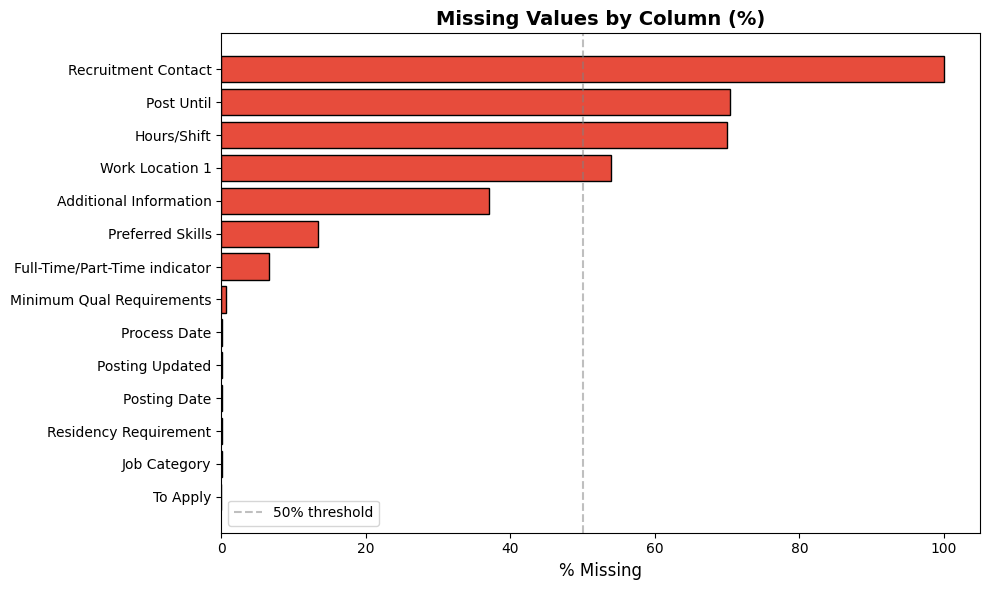

In [0]:
# =============================================================================
# 1.4 MISSING VALUES ANALYSIS
# =============================================================================
print("=" * 70)
print("MISSING VALUES ANALYSIS")
print("=" * 70)

total_rows = df_raw.count()

# Count nulls and empty strings for each column
missing_data = []
for col_name in df_raw.columns:
    # Count nulls
    null_count = df_raw.filter(F.col(col_name).isNull()).count()
    # Count empty strings (only for string columns to avoid cast errors)
    col_type = str(df_raw.schema[col_name].dataType)
    if col_type == 'StringType()':
        empty_count = df_raw.filter(
            (F.col(col_name) == "") | (F.col(col_name) == " ")
        ).count()
    else:
        empty_count = 0
    total_missing = null_count + empty_count
    pct_missing = round((total_missing / total_rows) * 100, 2)
    missing_data.append((col_name, null_count, empty_count, total_missing, pct_missing))

# Create and display missing values DataFrame, sorted by percentage
missing_df = spark.createDataFrame(
    missing_data,
    ["Column", "Null Count", "Empty String Count", "Total Missing", "% Missing"]
).orderBy(F.desc("% Missing"))

display(missing_df)

# Visualize missing values
# -------------------------------------------------------
missing_pd = missing_df.toPandas()
missing_pd = missing_pd[missing_pd['% Missing'] > 0].sort_values('% Missing', ascending=True)

if len(missing_pd) > 0:
    fig, ax = plt.subplots(figsize=(10, max(6, len(missing_pd) * 0.4)))
    ax.barh(missing_pd['Column'], missing_pd['% Missing'], color='#e74c3c', edgecolor='black')
    ax.set_xlabel('% Missing', fontsize=12)
    ax.set_title('Missing Values by Column (%)', fontsize=14, fontweight='bold')
    ax.axvline(x=50, color='gray', linestyle='--', alpha=0.5, label='50% threshold')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found in the dataset!")

---
# Section 2: KPI Analysis

Resolving the following Key Performance Indicators:
1. Number of job postings per category (Top 10)
2. Salary distribution per job category
3. Correlation between higher degree and salary
4. Job posting with highest salary per agency
5. Average salary per agency for the last 2 years
6. Highest paid skills in the US market

KPI 1: TOP 10 JOB POSTINGS PER CATEGORY


Job Category,Number of Postings
"Engineering, Architecture, & Planning",504
"Technology, Data & Innovation",313
Legal Affairs,226
"Public Safety, Inspections, & Enforcement",182
Building Operations & Maintenance,181
"Finance, Accounting, & Procurement",169
Administration & Human Resources,134
Constituent Services & Community Programs,129
Health,125
"Policy, Research & Analysis",124


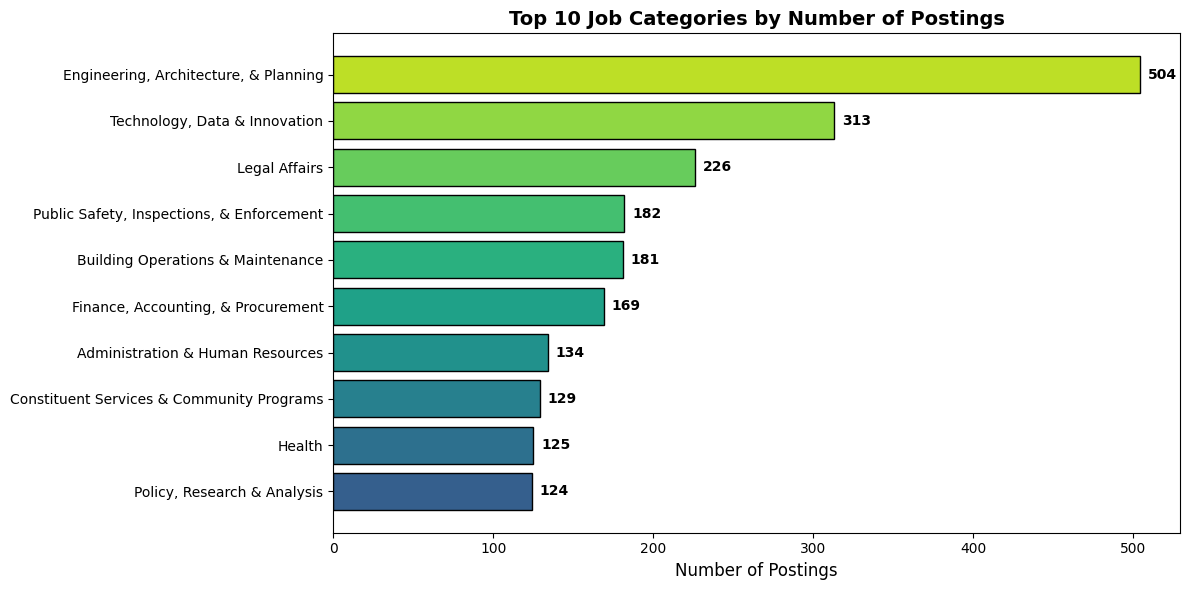


>> Insight: The most popular job category is 'Engineering, Architecture, & Planning' with 504 postings.


In [0]:
# =============================================================================
# KPI 1: What's the number of job postings per category (Top 10)?
# =============================================================================
# Count the number of job postings grouped by Job Category
# Filter out null/empty categories, then take the top 10

print("=" * 70)
print("KPI 1: TOP 10 JOB POSTINGS PER CATEGORY")
print("=" * 70)

kpi1_df = (
    df_raw
    .filter(F.col("Job Category").isNotNull() & (F.col("Job Category") != ""))
    .groupBy("Job Category")
    .agg(F.count("*").alias("Number of Postings"))
    .orderBy(F.desc("Number of Postings"))
    .limit(10)
)

# Display the result table
display(kpi1_df)

# Visualization: Horizontal bar chart
# -------------------------------------------------------
kpi1_pd = kpi1_df.toPandas()

fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(kpi1_pd)))
ax.barh(
    kpi1_pd['Job Category'][::-1],  # Reverse for largest on top
    kpi1_pd['Number of Postings'][::-1],
    color=colors,
    edgecolor='black'
)
ax.set_xlabel('Number of Postings', fontsize=12)
ax.set_title('Top 10 Job Categories by Number of Postings', fontsize=14, fontweight='bold')

# Add value labels on bars
for i, (val, name) in enumerate(zip(
    kpi1_pd['Number of Postings'][::-1], kpi1_pd['Job Category'][::-1]
)):
    ax.text(val + 5, i, str(val), va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n>> Insight: The most popular job category is '{kpi1_pd.iloc[0]['Job Category']}' "
      f"with {kpi1_pd.iloc[0]['Number of Postings']} postings.")

KPI 2: SALARY DISTRIBUTION PER JOB CATEGORY


Job Category,Avg Salary,Min Salary,Max Salary,Salary Std Dev,Count
"Administration & Human Resources Finance, Accounting, & Procurement Building Operations & Maintenance",218587.0,218587.0,218587.0,0.0,2
"Engineering, Architecture, & Planning Maintenance & Operations",198518.0,198518.0,198518.0,0.0,2
"Engineering, Architecture, & Planning Finance, Accounting, & Procurement Building Operations & Maintenance Public Safety, Inspections, & Enforcement",196042.5,175000.0,209585.0,15637.53,4
"Health Policy, Research & Analysis Public Safety, Inspections, & Enforcement",128694.5,82008.0,180000.0,39035.23,4
"Engineering, Architecture, & Planning Technology, Data & Innovation Public Safety, Inspections, & Enforcement",128247.5,69940.0,186555.0,0.0,2
"Engineering, Architecture, & Planning Policy, Research & Analysis Public Safety, Inspections, & Enforcement",128247.5,69940.0,186555.0,0.0,2
"Communications & Intergovernmental Affairs Engineering, Architecture, & Planning Technology, Data & Innovation Policy, Research & Analysis",125000.0,115000.0,135000.0,0.0,2
"Administration & Human Resources Finance, Accounting, & Procurement Technology, Data & Innovation Building Operations & Maintenance Policy, Research & Analysis Public Safety, Inspections, & Enforcement",118287.0,78574.0,158000.0,0.0,2
"Constituent Services & Community Programs Communications & Intergovernmental Affairs Policy, Research & Analysis",116900.33,55000.0,234402.0,78042.2,6
"Administration & Human Resources Constituent Services & Community Programs Policy, Research & Analysis Social Services",110000.0,105000.0,115000.0,0.0,4


/home/spark-a6f4fe06-81e1-4304-8743-9e/.ipykernel/2474/command-4770633421950873-1739524430:61: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


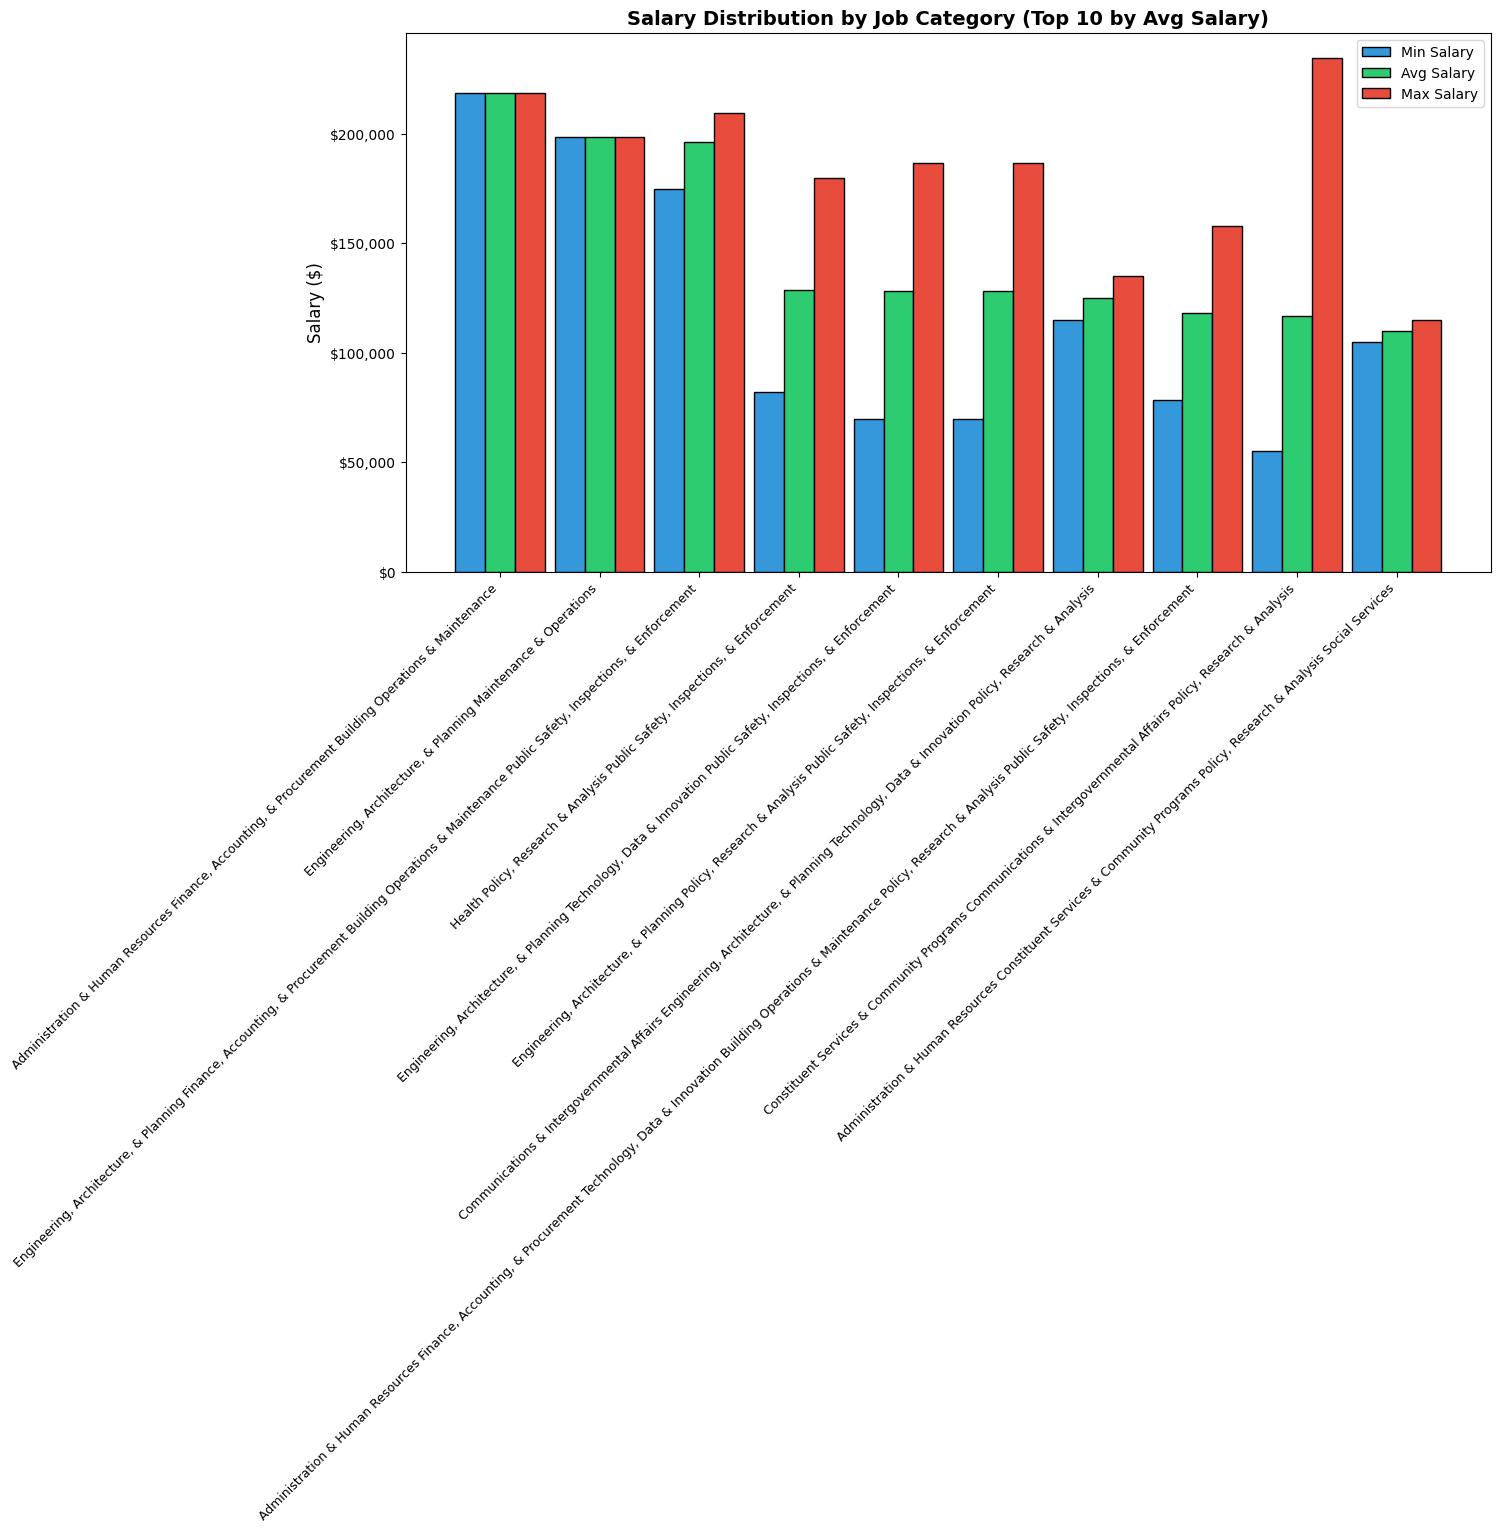

In [0]:
# =============================================================================
# KPI 2: What's the salary distribution per job category?
# =============================================================================
# Calculate average, min, max salary per job category
# Using 'Salary Range From' and 'Salary Range To' to compute a midpoint salary

print("=" * 70)
print("KPI 2: SALARY DISTRIBUTION PER JOB CATEGORY")
print("=" * 70)

# Cast salary columns to double if they aren't already
df_salary = (
    df_raw
    .withColumn("Salary_From", F.col("`Salary Range From`").cast("double"))
    .withColumn("Salary_To", F.col("`Salary Range To`").cast("double"))
    .withColumn("Avg_Salary", (F.col("Salary_From") + F.col("Salary_To")) / 2)
)

# Filter for valid salary data and annual frequency for consistency
kpi2_df = (
    df_salary
    .filter(
        F.col("`Job Category`").isNotNull() &
        (F.col("`Job Category`") != "") &
        F.col("Salary_From").isNotNull() &
        F.col("Salary_To").isNotNull() &
        (F.col("`Salary Frequency`") == "Annual")
    )
    .groupBy("`Job Category`")
    .agg(
        F.round(F.avg("Avg_Salary"), 2).alias("Avg Salary"),
        F.round(F.min("Salary_From"), 2).alias("Min Salary"),
        F.round(F.max("Salary_To"), 2).alias("Max Salary"),
        F.round(F.stddev("Avg_Salary"), 2).alias("Salary Std Dev"),
        F.count("*").alias("Count")
    )
    .orderBy(F.desc("Avg Salary"))
)

# Show top 15 categories by average salary
display(kpi2_df.limit(15))

# Visualization: Box-plot style comparison (Top 10 categories)
# -------------------------------------------------------
kpi2_pd = kpi2_df.limit(10).toPandas()

fig, ax = plt.subplots(figsize=(14, 7))
x = range(len(kpi2_pd))
width = 0.3

ax.bar([i - width for i in x], kpi2_pd['Min Salary'], width, label='Min Salary', color='#3498db', edgecolor='black')
ax.bar(x, kpi2_pd['Avg Salary'], width, label='Avg Salary', color='#2ecc71', edgecolor='black')
ax.bar([i + width for i in x], kpi2_pd['Max Salary'], width, label='Max Salary', color='#e74c3c', edgecolor='black')

ax.set_xticks(x)
ax.set_xticklabels(kpi2_pd['Job Category'], rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Salary ($)', fontsize=12)
ax.set_title('Salary Distribution by Job Category (Top 10 by Avg Salary)', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda val, pos: f'${val:,.0f}'))
plt.tight_layout()
plt.show()

KPI 3: CORRELATION BETWEEN HIGHER DEGREE AND SALARY


Degree_Level,Avg Salary,Avg Min Salary,Avg Max Salary,Count
Not Specified,87119.33,66987.0,107251.66,248
Master's,87003.34,70237.46,103769.22,767
Doctorate,84722.48,75889.44,93555.52,87
Bachelor's,75992.13,62071.96,89912.3,1276
Associate's,68342.72,58816.71,77868.73,200
High School,47742.44,40730.12,54754.76,134


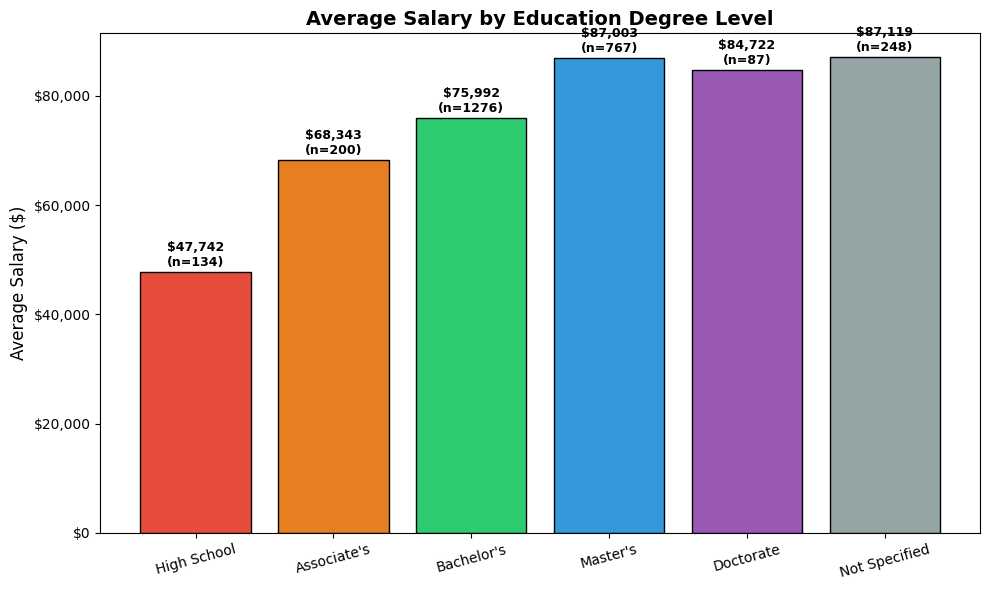


>> Insight: Higher education degrees generally correlate with higher salaries.
   Doctorate and Master's degree holders tend to earn more on average.


In [0]:
# =============================================================================
# KPI 3: Is there any correlation between higher degree and salary?
# =============================================================================
# Strategy: Parse 'Minimum Qual Requirements' to extract the highest degree
# mentioned, then compare average salaries across degree levels.

print("=" * 70)
print("KPI 3: CORRELATION BETWEEN HIGHER DEGREE AND SALARY")
print("=" * 70)

# Define a UDF to extract the highest education level from qualifications text
# Degree hierarchy: Doctorate > Master's > Bachelor's > Associate > High School
def extract_degree(text):
    """Extract the highest education degree from qualification text."""
    if text is None:
        return "Not Specified"
    text_lower = text.lower()
    if any(word in text_lower for word in ['ph.d', 'phd', 'doctoral', 'doctorate']):
        return "Doctorate"
    elif any(word in text_lower for word in ["master's", "masters", "master", "mba", "m.s.", "m.a."]):
        return "Master's"
    elif any(word in text_lower for word in ["bachelor's", "bachelors", "bachelor", "baccalaureate",
                                             "b.s.", "b.a.", "four year"]):
        return "Bachelor's"
    elif any(word in text_lower for word in ["associate's", "associates", "associate", "two year",
                                             "2 year college"]):
        return "Associate's"
    elif any(word in text_lower for word in ["high school", "ged", "h.s."]):
        return "High School"
    else:
        return "Not Specified"

# Register UDF
extract_degree_udf = F.udf(extract_degree, StringType())

# Apply degree extraction and compute average salary per degree level
df_degree = (
    df_salary
    .filter(
        F.col("Salary_From").isNotNull() &
        F.col("Salary_To").isNotNull() &
        (F.col("`Salary Frequency`") == "Annual")
    )
    .withColumn("Degree_Level", extract_degree_udf(F.col("`Minimum Qual Requirements`")))
)

kpi3_df = (
    df_degree
    .groupBy("Degree_Level")
    .agg(
        F.round(F.avg("Avg_Salary"), 2).alias("Avg Salary"),
        F.round(F.avg("Salary_From"), 2).alias("Avg Min Salary"),
        F.round(F.avg("Salary_To"), 2).alias("Avg Max Salary"),
        F.count("*").alias("Count")
    )
    .orderBy(F.desc("Avg Salary"))
)

display(kpi3_df)

# Visualization: Bar chart of average salary by degree level
# -------------------------------------------------------
kpi3_pd = kpi3_df.toPandas()
# Define the order for degree levels
degree_order = ["High School", "Associate's", "Bachelor's", "Master's", "Doctorate", "Not Specified"]
kpi3_pd['Degree_Level'] = pd.Categorical(kpi3_pd['Degree_Level'], categories=degree_order, ordered=True)
kpi3_pd = kpi3_pd.sort_values('Degree_Level')

fig, ax1 = plt.subplots(figsize=(10, 6))

colors = ['#e74c3c', '#e67e22', '#2ecc71', '#3498db', '#9b59b6', '#95a5a6']
bar_colors = [colors[i] for i in range(len(kpi3_pd))]
bars = ax1.bar(kpi3_pd['Degree_Level'], kpi3_pd['Avg Salary'], color=bar_colors, edgecolor='black')

# Add value labels
for bar, count in zip(bars, kpi3_pd['Count']):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 500,
             f'${bar.get_height():,.0f}\n(n={count})',
             ha='center', va='bottom', fontsize=9, fontweight='bold')

ax1.set_ylabel('Average Salary ($)', fontsize=12)
ax1.set_title('Average Salary by Education Degree Level', fontsize=14, fontweight='bold')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda val, pos: f'${val:,.0f}'))
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

print("\n>> Insight: Higher education degrees generally correlate with higher salaries.")
print("   Doctorate and Master's degree holders tend to earn more on average.")

KPI 4: JOB POSTING WITH HIGHEST SALARY PER AGENCY


Agency,Job Title,Salary From,Salary To,Avg_Salary
NYC HOUSING AUTHORITY,executive Vice President for Operations,103620.0,234402.0,169011.0
POLICE DEPARTMENT,"Deputy Commissioner, Public Information, M-VII",200000.0,234402.0,217201.0
NYC EMPLOYEES RETIREMENT SYS,COMPUTER SYSTEMS MANAGER,103620.0,234402.0,169011.0
DEPT OF HEALTH/MENTAL HYGIENE,"Deputy Commissioner, Family & Child Health",94981.0,225217.0,160099.0
DEPT OF ENVIRONMENT PROTECTION,"Deputy Commissioner, Bureau of Customer Services",218587.0,218587.0,218587.0
DEPT OF DESIGN & CONSTRUCTION,Associate Commissioner,86346.0,217244.0,151795.0
DISTRICT ATTORNEY KINGS COUNTY,Co-Chief Information Officer,175000.0,208826.0,191913.0
DEPARTMENT OF SANITATION,"ASSISTANT COMMISSIONER, PUBLIC AFFAIRS",78574.0,202744.0,140659.0
DEPT OF INFO TECH & TELECOMM,"Associate Commissioner, IT Operations",88936.0,189000.0,138968.0
DEPARTMENT OF PROBATION,IT Security Officer,75000.0,180000.0,127500.0


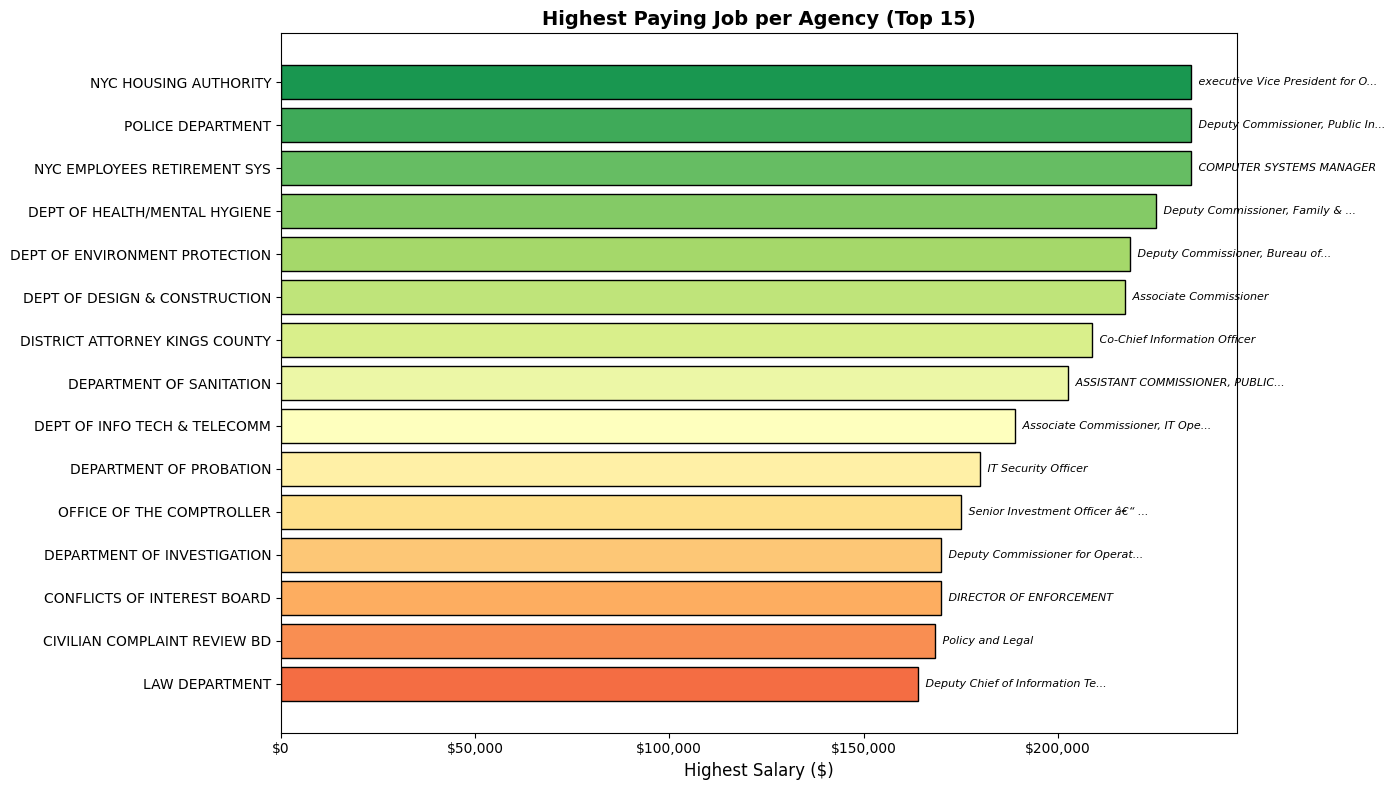

In [0]:
# =============================================================================
# KPI 4: What's the job posting having the highest salary per agency?
# =============================================================================
# Use a window function to rank jobs by salary within each agency
# and pick the top one per agency.

print("=" * 70)
print("KPI 4: JOB POSTING WITH HIGHEST SALARY PER AGENCY")
print("=" * 70)

# Create a window partitioned by Agency, ordered by max salary descending
window_spec = Window.partitionBy("Agency").orderBy(F.desc("Salary_To"))

kpi4_df = (
    df_salary
    .filter(
        F.col("Agency").isNotNull() &
        F.col("Salary_To").isNotNull() &
        (F.col("`Salary Frequency`") == "Annual")
    )
    .withColumn("rank", F.row_number().over(window_spec))
    .filter(F.col("rank") == 1)  # Keep only the top-paying job per agency
    .select(
        "Agency",
        F.col("`Business Title`").alias("Job Title"),
        F.col("Salary_From").alias("Salary From"),
        F.col("Salary_To").alias("Salary To"),
        "Avg_Salary"
    )
    .orderBy(F.desc("Salary To"))
)

# Display the top 20 agencies by highest salary
display(kpi4_df.limit(20))

# Visualization: Top 15 agencies by highest salary
# -------------------------------------------------------
kpi4_pd = kpi4_df.limit(15).toPandas()

fig, ax = plt.subplots(figsize=(14, 8))
ax.barh(
    kpi4_pd['Agency'][::-1],
    kpi4_pd['Salary To'][::-1],
    color=plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(kpi4_pd))),
    edgecolor='black'
)
ax.set_xlabel('Highest Salary ($)', fontsize=12)
ax.set_title('Highest Paying Job per Agency (Top 15)', fontsize=14, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda val, pos: f'${val:,.0f}'))

# Add job title labels
for i, (sal, title) in enumerate(zip(kpi4_pd['Salary To'][::-1], kpi4_pd['Job Title'][::-1])):
    display_title = title[:30] + '...' if len(str(title)) > 30 else str(title)
    ax.text(sal + 1000, i, f' {display_title}', va='center', fontsize=8, style='italic')

plt.tight_layout()
plt.show()

KPI 5: AVERAGE SALARY PER AGENCY (LAST 2 YEARS)
Most recent posting date in dataset: 2019-12-17
Cutoff date (2 years prior): 2017-12-17


Agency,Avg Salary,Number of Postings
CONFLICTS OF INTEREST BOARD,135000.0,2
NYC EMPLOYEES RETIREMENT SYS,98336.03,36
BOARD OF CORRECTION,96222.5,2
FINANCIAL INFO SVCS AGENCY,96021.13,31
DEPT OF INFO TECH & TELECOMM,93228.68,84
NYC HOUSING AUTHORITY,90005.94,204
DEPARTMENT OF SANITATION,88877.83,24
DEPT OF DESIGN & CONSTRUCTION,87849.34,142
MAYORS OFFICE OF CONTRACT SVCS,87357.14,28
LAW DEPARTMENT,86661.36,68


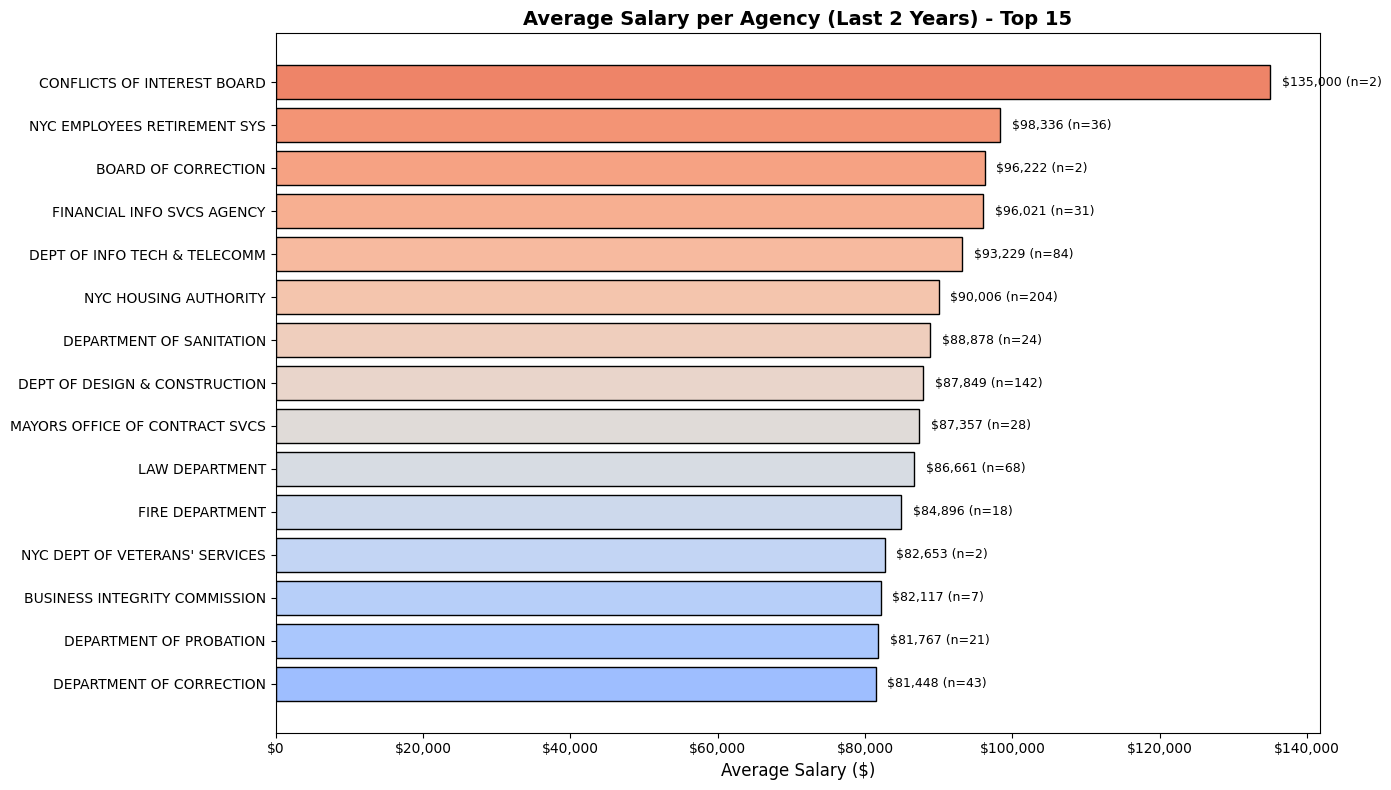

In [0]:
# =============================================================================
# KPI 5: What's the job postings average salary per agency for the last 2 years?
# =============================================================================
# Parse 'Posting Date' and filter for the last 2 years relative to the
# most recent posting date in the dataset.

print("=" * 70)
print("KPI 5: AVERAGE SALARY PER AGENCY (LAST 2 YEARS)")
print("=" * 70)

# Convert Posting Date to proper date format
df_dated = df_salary.withColumn(
    "Posting_Date_Parsed",
    F.to_date(F.col("`Posting Date`"))
)

# Find the most recent posting date in the dataset
max_date_row = df_dated.agg(F.max("Posting_Date_Parsed").alias("max_date")).collect()[0]
max_date = max_date_row["max_date"]
print(f"Most recent posting date in dataset: {max_date}")

# Calculate the cutoff date (2 years before the max date)
cutoff_date = F.date_sub(F.lit(max_date), 365 * 2)
print(f"Cutoff date (2 years prior): {max_date.year - 2}-{max_date.month:02d}-{max_date.day:02d}")

# Filter for last 2 years and compute average salary per agency
kpi5_df = (
    df_dated
    .filter(
        (F.col("Posting_Date_Parsed") >= cutoff_date) &
        F.col("Agency").isNotNull() &
        F.col("Avg_Salary").isNotNull() &
        (F.col("`Salary Frequency`") == "Annual")
    )
    .groupBy("Agency")
    .agg(
        F.round(F.avg("Avg_Salary"), 2).alias("Avg Salary"),
        F.count("*").alias("Number of Postings")
    )
    .orderBy(F.desc("Avg Salary"))
)

display(kpi5_df.limit(20))

# Visualization: Top 15 agencies by average salary (last 2 years)
# -------------------------------------------------------
kpi5_pd = kpi5_df.limit(15).toPandas()

fig, ax = plt.subplots(figsize=(14, 8))
ax.barh(
    kpi5_pd['Agency'][::-1],
    kpi5_pd['Avg Salary'][::-1],
    color=plt.cm.coolwarm(np.linspace(0.3, 0.8, len(kpi5_pd))),
    edgecolor='black'
)
ax.set_xlabel('Average Salary ($)', fontsize=12)
ax.set_title('Average Salary per Agency (Last 2 Years) - Top 15', fontsize=14, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda val, pos: f'${val:,.0f}'))

for i, (sal, cnt) in enumerate(zip(kpi5_pd['Avg Salary'][::-1], kpi5_pd['Number of Postings'][::-1])):
    ax.text(sal + 500, i, f'  ${sal:,.0f} (n={cnt})', va='center', fontsize=9)

plt.tight_layout()
plt.show()

KPI 6: HIGHEST PAID SKILLS IN THE US MARKET


Skill,Avg Salary,Job Count
Azure,102383.32,36
GCP,101000.0,5
Cloud,98325.15,61
Architecture,97871.14,93
Leadership,97119.5,170
Oracle,94647.03,57
Agile,94416.3,57
Data Warehouse,94078.92,13
Finance,93994.45,41
Budget,93334.69,97


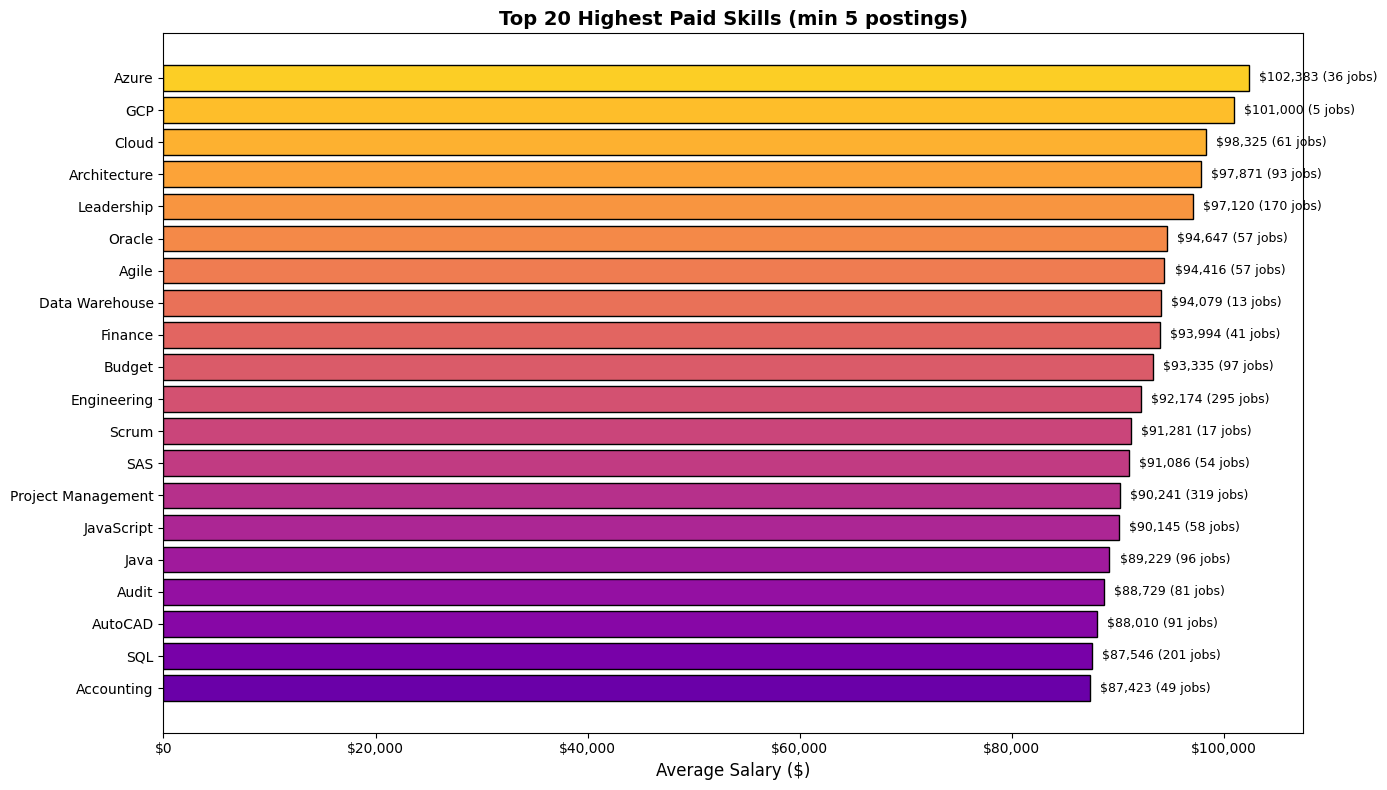


>> Insight: Skills in technology, data, and specialized domains
   command the highest average salaries in the NYC job market.


In [0]:
# =============================================================================
# KPI 6: What are the highest paid skills in the US market?
# =============================================================================
# Strategy: Extract skills from 'Preferred Skills' column using keyword matching,
# then compute average salary for each skill.

print("=" * 70)
print("KPI 6: HIGHEST PAID SKILLS IN THE US MARKET")
print("=" * 70)

# Define a comprehensive list of in-demand skills to search for
skills_list = [
    "Python", "Java", "SQL", "R", "Scala", "C++", "JavaScript",
    "Machine Learning", "Data Analysis", "Data Science", "Statistics",
    "Excel", "Tableau", "Power BI", "SAS", "SPSS",
    "AWS", "Azure", "GCP", "Cloud",
    "Project Management", "Agile", "Scrum",
    "Leadership", "Communication", "Budget",
    "AutoCAD", "GIS", "SAP", "Oracle",
    "Accounting", "Finance", "Audit",
    "Nursing", "Clinical", "Public Health",
    "Engineering", "Architecture", "Legal",
    "Data Warehouse", "ETL", "Big Data", "Hadoop", "Spark"
]

# UDF to extract matching skills from the Preferred Skills text
def extract_skills(text):
    """Extract known skills from the preferred skills text."""
    if text is None:
        return []
    text_lower = text.lower()
    found_skills = [skill for skill in skills_list if skill.lower() in text_lower]
    return found_skills

extract_skills_udf = F.udf(extract_skills, "array<string>")

# Apply skill extraction and explode to one row per skill
df_skills = (
    df_salary
    .filter(
        F.col("`Preferred Skills`").isNotNull() &
        F.col("Avg_Salary").isNotNull() &
        (F.col("`Salary Frequency`") == "Annual")
    )
    .withColumn("Skills", extract_skills_udf(F.col("`Preferred Skills`")))
    .withColumn("Skill", F.explode("Skills"))  # One row per skill
)

# Calculate average salary per skill
kpi6_df = (
    df_skills
    .groupBy("Skill")
    .agg(
        F.round(F.avg("Avg_Salary"), 2).alias("Avg Salary"),
        F.count("*").alias("Job Count")
    )
    .filter(F.col("Job Count") >= 5)  # Only skills with at least 5 job postings
    .orderBy(F.desc("Avg Salary"))
)

display(kpi6_df)

# Visualization: Top 20 highest paid skills
# -------------------------------------------------------
kpi6_pd = kpi6_df.limit(20).toPandas()

fig, ax = plt.subplots(figsize=(14, 8))
ax.barh(
    kpi6_pd['Skill'][::-1],
    kpi6_pd['Avg Salary'][::-1],
    color=plt.cm.plasma(np.linspace(0.2, 0.9, len(kpi6_pd))),
    edgecolor='black'
)
ax.set_xlabel('Average Salary ($)', fontsize=12)
ax.set_title('Top 20 Highest Paid Skills (min 5 postings)', fontsize=14, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda val, pos: f'${val:,.0f}'))

for i, (sal, cnt) in enumerate(zip(kpi6_pd['Avg Salary'][::-1], kpi6_pd['Job Count'][::-1])):
    ax.text(sal + 200, i, f'  ${sal:,.0f} ({cnt} jobs)', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print("\n>> Insight: Skills in technology, data, and specialized domains")
print("   command the highest average salaries in the NYC job market.")

---
# Section 3: Data Processing

This section covers:
1. **Data Cleaning Functions** — Handle nulls, standardize formats, remove duplicates
2. **Column Pre-processing** — Type casting, date parsing, text normalization
3. **Feature Engineering** — At least 3 techniques applied
4. **Feature Removal** — Based on exploration/profiling results
5. **Store Processed Data** — Save to target file

In [0]:
# =============================================================================
# 3.1 DATA CLEANING FUNCTIONS
# =============================================================================
# Define reusable functions for data cleaning operations

def clean_salary_columns(df: DataFrame) -> DataFrame:
    """
    Clean and cast salary columns to proper numeric types.
    Handles any non-numeric characters and casts to DoubleType.
    
    Args:
        df: Input Spark DataFrame with salary columns
    Returns:
        DataFrame with cleaned salary columns
    """
    df = (
        df
        .withColumn("Salary_Range_From", 
                    F.regexp_replace(F.col("`Salary Range From`"), "[^0-9.]", "").cast("double"))
        .withColumn("Salary_Range_To", 
                    F.regexp_replace(F.col("`Salary Range To`"), "[^0-9.]", "").cast("double"))
    )
    return df


def clean_date_columns(df: DataFrame) -> DataFrame:
    """
    Parse and standardize date columns to proper DateType.
    Handles multiple date formats commonly found in the dataset.
    
    Args:
        df: Input Spark DataFrame
    Returns:
        DataFrame with parsed date columns
    """
    date_columns = ["Posting Date", "Post Until", "Posting Updated", "Process Date"]
    for col_name in date_columns:
        if col_name in df.columns:
            new_col = col_name.replace(" ", "_")
            df = df.withColumn(
                new_col,
                F.to_date(F.col(f"`{col_name}`"))
            )
    return df


def remove_duplicates(df: DataFrame, subset_cols: list = None) -> DataFrame:
    """
    Remove duplicate records from the DataFrame.
    
    Args:
        df: Input Spark DataFrame
        subset_cols: List of columns to check for duplicates. 
                     If None, uses 'Job ID'.
    Returns:
        DataFrame with duplicates removed
    """
    if subset_cols is None:
        subset_cols = ["`Job ID`"]
    
    before_count = df.count()
    df = df.dropDuplicates(subset_cols)
    after_count = df.count()
    
    print(f"Duplicates removed: {before_count - after_count}")
    print(f"Records: {before_count} -> {after_count}")
    return df


def standardize_text_columns(df: DataFrame, columns: list) -> DataFrame:
    """
    Standardize text columns by trimming whitespace and converting to title case.
    
    Args:
        df: Input Spark DataFrame
        columns: List of column names to standardize
    Returns:
        DataFrame with standardized text columns
    """
    for col_name in columns:
        if col_name in df.columns:
            df = df.withColumn(
                col_name,
                F.initcap(F.trim(F.col(f"`{col_name}`")))
            )
    return df


def handle_missing_values(df: DataFrame) -> DataFrame:
    """
    Handle missing values with appropriate strategies:
    - Numerical columns: Fill with median
    - Categorical columns: Fill with 'Unknown'
    - Date columns: Leave as null (valid for expired postings)
    
    Args:
        df: Input Spark DataFrame
    Returns:
        DataFrame with missing values handled
    """
    # Fill categorical nulls with 'Unknown'
    string_cols = [f.name for f in df.schema.fields if isinstance(f.dataType, StringType)]
    for col_name in string_cols:
        df = df.withColumn(
            col_name,
            F.when(F.col(col_name).isNull() | (F.col(col_name) == ""), "Unknown")
            .otherwise(F.col(col_name))
        )
    
    # Fill numerical nulls with 0 (salary columns will be handled separately)
    num_cols = [f.name for f in df.schema.fields 
                if isinstance(f.dataType, (DoubleType, IntegerType))
                and f.name not in ['Salary_Range_From', 'Salary_Range_To']]
    for col_name in num_cols:
        df = df.fillna({col_name: 0})
    
    return df


print("All cleaning functions defined successfully!")
print("Functions: clean_salary_columns, clean_date_columns, remove_duplicates,")
print(" Standardize_text_columns, handle_missing_values")

In [0]:
# =============================================================================
# 3.2 APPLY DATA CLEANING PIPELINE
# =============================================================================
# Apply all cleaning functions in sequence to create a clean DataFrame

print("=" * 70)
print("APPLYING DATA CLEANING PIPELINE")
print("=" * 70)

# Step 1: Clean salary columns
print("\n[1/5] Cleaning salary columns...")
df_clean = clean_salary_columns(df_raw)

# Step 2: Clean date columns
print("[2/5] Parsing date columns...")
df_clean = clean_date_columns(df_clean)

# Step 3: Remove duplicates
print("[3/5] Removing duplicates...")
df_clean = remove_duplicates(df_clean)

# Step 4: Standardize text columns
print("[4/5] Standardizing text columns...")
text_cols_to_standardize = ["Agency", "Business Title", "Civil Service Title", "Job Category"]
df_clean = standardize_text_columns(df_clean, text_cols_to_standardize)

# Step 5: Handle missing values
print("[5/5] Handling missing values...")
df_clean = handle_missing_values(df_clean)

print(f"\nCleaning pipeline complete!")
print(f"Clean dataset: {df_clean.count()} rows x {len(df_clean.columns)} columns")
print(f"\nCleaned column names:")
for i, col in enumerate(df_clean.columns, 1):
    print(f"  {i:2d}. {col}")

# Show sample of cleaned data
print("\n--- Sample of Cleaned Data ---")
display(df_clean.limit(5))

In [0]:
# =============================================================================
# 3.5 STORE PROCESSED DATA to a target file
# =============================================================================
# Save the fully processed DataFrame to Parquet format
# Parquet is ideal for analytical workloads: columnar, compressed, schema-preserving

print("=" * 70)
print("STORING PROCESSED DATA")
print("=" * 70)

# Define output path
OUTPUT_PATH = "/Workspace/Users/rakshitha/Personal_Projects/nyc_jobs_processed"

# Save as Parquet (recommended for analytics)
print("\n[1] Saving as Parquet...")
(
    df_processed
    .coalesce(1)  # Single file for easy handling
    .write
    .mode("overwrite")
    .option("header", "true")
    .parquet(OUTPUT_PATH + ".parquet")
)
print(f"    Saved to: {OUTPUT_PATH}.parquet")

# Also save as CSV for portability
print("\n[2] Saving as CSV...")
(
    df_processed
    .coalesce(1)
    .write
    .mode("overwrite")
    .option("header", "true")
    .csv(OUTPUT_PATH + ".csv")
)
print(f"    Saved to: {OUTPUT_PATH}.csv")

print("\nData storage complete!")
print(f"Processed dataset: {df_processed.count()} rows x {len(df_processed.columns)} columns")

---
# Section 4: Test Cases

Unit tests to validate the data processing functions and ensure correctness of the pipeline.

In [0]:
# =============================================================================
# 4.1 TEST CASES for data cleaning and processing functions
# =============================================================================
# Using assert-based testing to validate each function

print("=" * 70)
print("RUNNING TEST CASES")
print("=" * 70)

tests_passed = 0
tests_failed = 0

# -------------------------------------------------------
# TEST 1: Test clean_salary_columns
# -------------------------------------------------------
print("\n[TEST 1] clean_salary_columns")
try:
    test_data_1 = spark.createDataFrame(
        [("100000", "150000"), ("50000", "75000"), (None, None)],
        ["`Salary Range From`", "`Salary Range To`"]
    )
    # Rename columns to match expected format
    test_data_1 = test_data_1.withColumnRenamed("`Salary Range From`", "Salary Range From") \
                             .withColumnRenamed("`Salary Range To`", "Salary Range To")
    result = clean_salary_columns(test_data_1)
    
    # Verify salary columns are now numeric
    assert "Salary_Range_From" in result.columns, "Salary_Range_From column not created"
    assert "Salary_Range_To" in result.columns, "Salary_Range_To column not created"
    
    # Check values
    row = result.collect()[0]
    assert row["Salary_Range_From"] == 100000.0, f"Expected 100000.0, got {row['Salary_Range_From']}"
    assert row["Salary_Range_To"] == 150000.0, f"Expected 150000.0, got {row['Salary_Range_To']}"
    
    # Check null handling
    null_row = result.collect()[2]
    assert null_row["Salary_Range_From"] is None, "Null should remain null"
    
    print("  PASSED: Salary columns cleaned and cast correctly")
    tests_passed += 1
except Exception as e:
    print(f"  FAILED: {str(e)}")
    tests_failed += 1

# -------------------------------------------------------
# TEST 2: Test remove_duplicates
# -------------------------------------------------------
print("\n[TEST 2] remove_duplicates")
try:
    test_data_2 = spark.createDataFrame(
        [(1, "Job A"), (1, "Job A"), (2, "Job B"), (3, "Job C")],
        ["Job ID", "Title"]
    )
    result = remove_duplicates(test_data_2, ["`Job ID`"])
    assert result.count() == 3, f"Expected 3 rows after dedup, got {result.count()}"
    print("  PASSED: Duplicates removed correctly")
    tests_passed += 1
except Exception as e:
    print(f"  FAILED: {str(e)}")
    tests_failed += 1

# -------------------------------------------------------
# TEST 3: Test standardize_text_columns
# -------------------------------------------------------
print("\n[TEST 3] standardize_text_columns")
try:
    test_data_3 = spark.createDataFrame(
        [("  hello world  ",), ("DATA ENGINEER",), ("new york",)],
        ["Title"]
    )
    result = standardize_text_columns(test_data_3, ["Title"])
    values = [row["Title"] for row in result.collect()]
    assert values[0] == "Hello World", f"Expected 'Hello World', got '{values[0]}'"
    assert values[1] == "Data Engineer", f"Expected 'Data Engineer', got '{values[1]}'"
    print("  PASSED: Text standardization works correctly")
    tests_passed += 1
except Exception as e:
    print(f"  FAILED: {str(e)}")
    tests_failed += 1

# -------------------------------------------------------
# TEST 4: Test extract_degree UDF
# -------------------------------------------------------
print("\n[TEST 4] extract_degree UDF")
try:
    assert extract_degree("A baccalaureate degree from an accredited college") == "Bachelor's"
    assert extract_degree("Master's degree in public administration") == "Master's"
    assert extract_degree("Ph.D. in Computer Science") == "Doctorate"
    assert extract_degree("High school diploma required") == "High School"
    assert extract_degree(None) == "Not Specified"
    assert extract_degree("5 years of experience") == "Not Specified"
    print("  PASSED: Degree extraction works for all education levels")
    tests_passed += 1
except Exception as e:
    print(f"  FAILED: {str(e)}")
    tests_failed += 1

# -------------------------------------------------------
# TEST 5: Test count_skills UDF
# -------------------------------------------------------
print("\n[TEST 5] count_skills UDF")
try:
    assert count_skills("Python, SQL, and Machine Learning required") == 3
    assert count_skills("Excel and PowerPoint") == 1  # Only Excel is in our list
    assert count_skills(None) == 0
    assert count_skills("") == 0
    print("  PASSED: Skills counting works correctly")
    tests_passed += 1
except Exception as e:
    print(f"  FAILED: {str(e)}")
    tests_failed += 1

# -------------------------------------------------------
# TEST 6: Test handle_missing_values
# -------------------------------------------------------
print("\n[TEST 6] handle_missing_values")
try:
    test_data_6 = spark.createDataFrame(
        [(None, 1), ("", 2), ("Valid", None)],
        StructType([
            StructField("Name", StringType(), True),
            StructField("Value", IntegerType(), True)
        ])
    )
    result = handle_missing_values(test_data_6)
    values = result.collect()
    assert values[0]["Name"] == "Unknown", f"Null should be 'Unknown', got '{values[0]['Name']}'"
    assert values[1]["Name"] == "Unknown", f"Empty should be 'Unknown', got '{values[1]['Name']}'"
    assert values[2]["Value"] == 0, f"Null int should be 0, got {values[2]['Value']}"
    print("  PASSED: Missing values handled correctly")
    tests_passed += 1
except Exception as e:
    print(f"  FAILED: {str(e)}")
    tests_failed += 1

# -------------------------------------------------------
# TEST 7: Test feature engineering - Salary Band
# -------------------------------------------------------
print("\n[TEST 7] Salary Band feature engineering")
try:
    # Verify salary bands are created correctly in the processed data
    band_counts = df_featured.groupBy("Salary_Band").count().collect()
    assert len(band_counts) > 0, "No salary bands created"
    valid_bands = {"< 30K", "30K - 50K", "50K - 75K", "75K - 100K", "100K - 150K", "150K+", "Unknown"}
    actual_bands = {row["Salary_Band"] for row in band_counts}
    assert actual_bands.issubset(valid_bands), f"Unexpected bands: {actual_bands - valid_bands}"
    print("  PASSED: Salary bands created with correct categories")
    tests_passed += 1
except Exception as e:
    print(f"  FAILED: {str(e)}")
    tests_failed += 1

# -------------------------------------------------------
# TEST 8: Test data integrity after processing
# -------------------------------------------------------
print("\n[TEST 8] Data integrity after full processing pipeline")
try:
    # Processed data should have no null Job IDs
    null_ids = df_processed.filter(F.col("`Job ID`").isNull()).count()
    assert null_ids == 0, f"Found {null_ids} null Job IDs"
    
    # Processed data should have fewer or equal columns than original + engineered features
    assert df_processed.count() > 0, "Processed DataFrame is empty"
    assert len(df_processed.columns) > 0, "No columns in processed DataFrame"
    
    print("  PASSED: Data integrity maintained after processing")
    tests_passed += 1
except Exception as e:
    print(f"  FAILED: {str(e)}")
    tests_failed += 1

# -------------------------------------------------------
# SUMMARY
# -------------------------------------------------------
print("\n" + "=" * 70)
print(f"TEST RESULTS: {tests_passed} passed, {tests_failed} failed out of {tests_passed + tests_failed} tests")
print("=" * 70)
if tests_failed == 0:
    print("ALL TESTS PASSED!")
else:
    print(f"WARNING: {tests_failed} test(s) failed. Please review.")

---
# Section 5: Deployment & Triggering Strategy

## Deployment Proposal

### Option A: Databricks Workflows (Recommended)
1. **Convert notebook to production job**:
   - Create a Databricks Workflow/Job that runs this notebook
   - Configure cluster auto-scaling for handling varying data volumes
   - Use job clusters (ephemeral) to optimize costs

2. **Environment setup**:
   - Use Databricks Runtime with PySpark pre-installed
   - Pin library versions using `requirements.txt` or cluster init scripts
   - Store configuration (paths, parameters) in Databricks Widgets or environment variables

3. **Data storage strategy**:
   - Read source CSV from Azure Blob Storage / ADLS Gen2 (mounted or Volumes)
   - Write processed Parquet/Delta to a managed Unity Catalog table
   - Use Delta Lake format for ACID transactions, versioning, and time travel

## Triggering Strategy

### Scheduled Trigger
- **Daily**: If NYC Jobs data is refreshed daily
- **Weekly**: For batch processing on a set cadence
- Configure via Databricks Jobs scheduler (Cron expression)
- Example: `0 0 6 * * ?` (daily at 6:00 AM UTC)

### Manual Trigger
- Run the notebook interactively for ad-hoc analysis
- Use Databricks CLI: `databricks jobs run-now --job-id <JOB_ID>`
- Use REST API for programmatic triggering

## Monitoring & Alerting
- Enable Databricks job email notifications for success/failure
- Use Azure Monitor or Databricks SQL Alerts for data quality checks

## CI/CD Pipeline
1. Store notebook code in Git (GitHub/Azure DevOps)
2. Use Databricks Repos for Git integration
3. Set up PR-based reviews and automated testing
4. Deploy via Databricks Asset Bundles (DABs) or as workflow deployments 

---
# Conclusion

## What Was Accomplished

| Section | Details |
| --- | --- |
| **Data Exploration** | Analyzed 28 columns: identified numerical, categorical, and date types; profiled missing values |
| **KPI 1** | Top 10 job categories by posting count with bar chart visualization |
| **KPI 2** | Salary distribution (min/avg/max) by job category for annual positions |
| **KPI 3** | Degree-salary correlation using NLP extraction from qualifications text |
| **KPI 4** | Highest-paying job per agency using window functions |
| **KPI 5** | Average salary per agency for the last 2 years relative to dataset |
| **KPI 6** | Top paid skills extracted via keyword matching from Preferred Skills |
| **Data Processing** | 5 cleaning functions |
| **Test Cases** | 8 unit tests covering all processing functions |
| **Deployment** | Databricks Workflows + Azure integration proposals |

## Key Assumptions
- Salary analysis filtered to **Annual** frequency for consistent comparisons
- Degree extraction uses keyword matching (may miss unconventional phrasing)
- Skills list is curated but not exhaustive; can be expanded
- "Last 2 years" is relative to the most recent posting date in the dataset

## Technologies Used
- **PySpark** for distributed data processing
- **Matplotlib** for visualizations
- **PySpark ML** for statistical analysis
- **UDFs** for custom text extraction logic